In [13]:
import xarray as xr 
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
df = xr.open_dataset('data/62X18X0.nc').to_dataframe()
df_ = sns.load_dataset('mpg').dropna()

<Axes: >

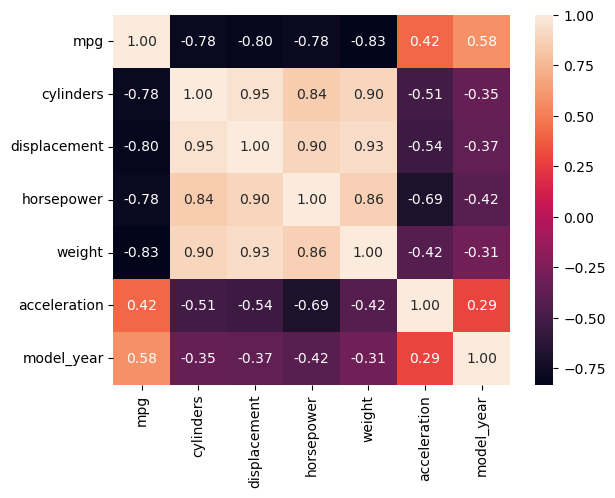

In [26]:
sns.heatmap(df_.corr(numeric_only=True), annot=True, fmt='.02f')

In [43]:
X = df_[['horsepower']]
Y = df_[['mpg']]

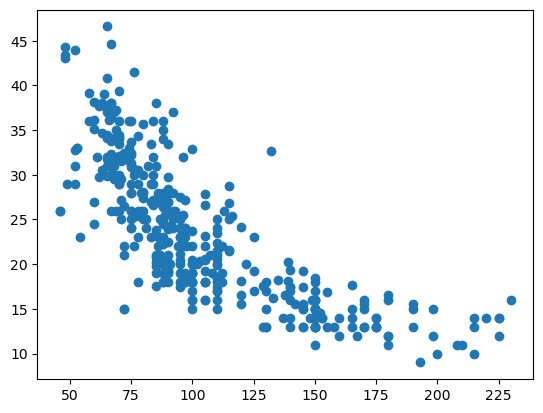

In [44]:
plt.scatter(X,Y)

# Most simple linear model

In [45]:
from sklearn.linear_model import LinearRegression

In [47]:
model = LinearRegression()
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


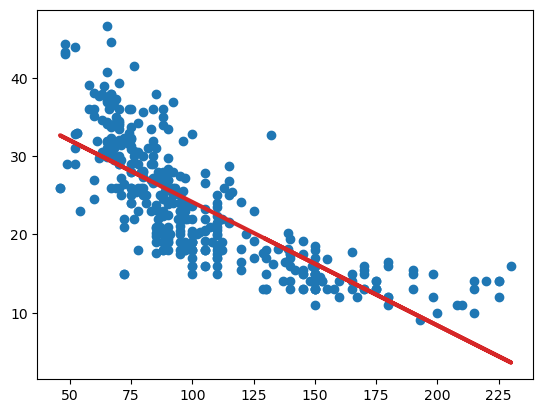

In [54]:
plt.scatter(X,Y)
plt.plot(X,model.predict(X), color='C3', lw=3)

In [71]:
X1 = df_[['horsepower','cylinders','displacement', 'model_year', 'weight', 'acceleration']]
Y = df_[['mpg']]

In [72]:
model = LinearRegression()
model.fit(X1,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


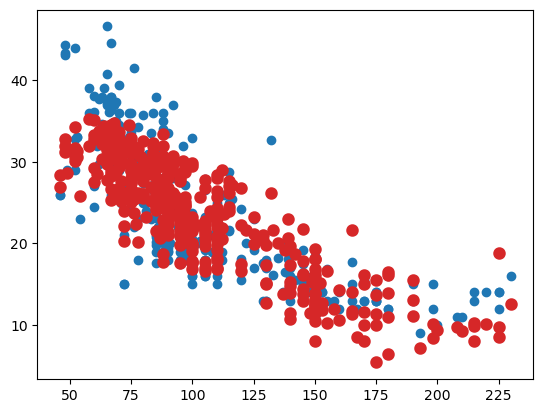

In [73]:
plt.scatter(X,Y)
plt.scatter(X,model.predict(X1), color='C3', lw=3)

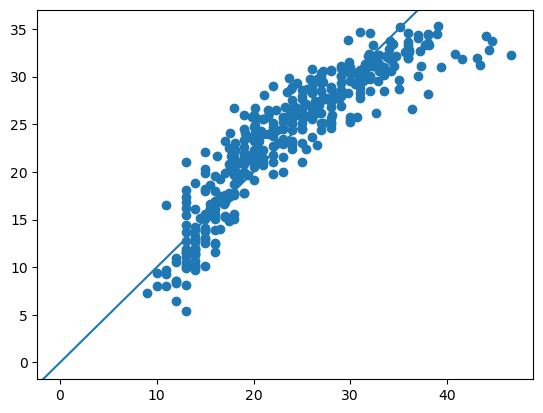

In [75]:
plt.scatter(Y, model.predict(X1))
plt.axline((0,0), slope=1)

# Classification

In [76]:
from sklearn import svm

In [77]:
model = svm.SVC()

In [78]:
df_

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [88]:
X = df_[['horsepower','cylinders','displacement', 'model_year', 'weight', 'acceleration', 'mpg']]
y = df_[['origin']].origin

In [89]:
model.fit(X, y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [96]:
preds = model.predict(X)
targets = df_.origin

from sklearn.metrics import confusion_matrix

In [97]:
confusion_matrix(preds, targets)

array([[  0,   0,   0],
       [ 38,  53,  28],
       [ 30,  26, 217]])

In [98]:
preds

array(['usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa',
       'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa',
       'japan', 'japan', 'usa', 'usa', 'usa', 'japan', 'usa', 'usa',
       'usa', 'usa', 'usa', 'japan', 'japan', 'japan', 'usa', 'usa',
       'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa',
       'usa', 'usa', 'usa', 'usa', 'usa', 'japan', 'japan', 'japan',
       'japan', 'japan', 'japan', 'japan', 'japan', 'japan', 'japan',
       'japan', 'usa', 'japan', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa',
       'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa',
       'usa', 'usa', 'japan', 'usa', 'japan', 'usa', 'japan', 'japan',
       'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa',
       'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'usa', 'japan',
       'usa', 'usa', 'usa', 'usa', 'usa', 'japan', 'usa', 'usa', 'japan',
       'japan', 'usa', 'japan', 'usa', 'usa', 'japan', 'japan', 'usa',
       'usa